<a href="https://colab.research.google.com/github/jadghazi/codealpha_tasks/blob/Intern_Tasks/Sales_Prediction_Data_Science_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset

url = "https://raw.githubusercontent.com/jadghazi/codealpha_tasks/refs/heads/Intern_Tasks/Advertising.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Drop the 'Unnamed: 0' column since it's just an index
df = df.drop('Unnamed: 0', axis=1)

# Check for null values
print(df.isnull().sum())

# Basic info
df.info()

# Quick stats
df.describe()


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


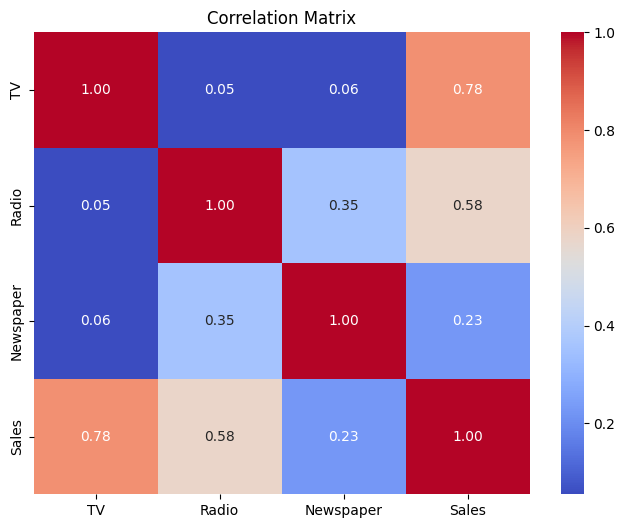

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [6]:
from sklearn.model_selection import train_test_split

# Features and target
X = df[['TV', 'Radio', 'Newspaper']]  # keep all for now
y = df['Sales']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Linear Regression metrics
print("📊 Linear Regression")
print("R² Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Random Forest Regressor metrics
print("\n🌲 Random Forest Regressor")
print("R² Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


📊 Linear Regression
R² Score: 0.899438024100912
MAE: 1.4607567168117603
MSE: 3.1740973539761033
RMSE: 1.78159966153345

🌲 Random Forest Regressor
R² Score: 0.9812843792541843
MAE: 0.6200999999999988
MSE: 0.5907322499999988
RMSE: 0.7685910811348248


In [9]:
# Drop 'Newspaper' from features
X = df[['TV', 'Radio']]
y = df['Sales']

# Train-test split again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train Random Forest
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("📊 Linear Regression (No Newspaper)")
print("R² Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("\n🌲 Random Forest Regressor (No Newspaper)")
print("R² Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


📊 Linear Regression (No Newspaper)
R² Score: 0.9005833101920356
RMSE: 1.7714254173033517

🌲 Random Forest Regressor (No Newspaper)
R² Score: 0.9864091117634538
RMSE: 0.6549635676890724


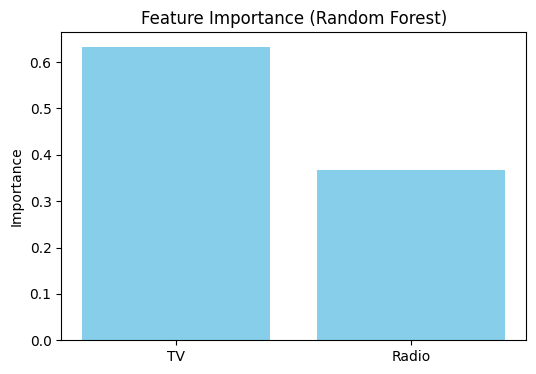

In [10]:
# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(6,4))
plt.bar(features, importances, color='skyblue')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()


###  Business Insights & Recommendations

- TV advertising has the strongest impact on sales, followed by **Radio**.
- Newspaper advertising had negligible influence and was removed to improve model performance.
- The Random Forest model achieved a R² of 0.986, indicating excellent predictive accuracy.
- A small increase in TV or Radio spending is likely to produce a measurable increase in sales.
- Recommend reallocating budget away from Newspaper toward TV and Radio, with an emphasis on TV for maximum return on investment.
